In [37]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Yuliia.Petrenko\OneDrive - Three60Energy\Working File Cloud\HR\L\netffix\netflix_data.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


In [38]:
#Filter the data for movies released in the 1990s
# df = df[
#     (df['type'] == 'Movie') &
#     (df['release_year'] >= 1990) &
#     (df['release_year'] <= 1999)
# ]
# df.head(5)

In [39]:
df=df[(df['type']=='Movie')&(df['release_year'].between(1990,1999,inclusive='both'))].reset_index(drop=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,119,After one of his high school students attacks ...,Dramas
1,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,"April 1, 2018",1993,101,At the center of this engrossing melodrama is ...,Dramas
2,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,"December 1, 2019",1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies
3,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,"December 1, 2020",1996,108,When a philandering club promoter sets out to ...,Comedies
4,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,"June 1, 2017",1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas


In [ ]:
#Find the most frequent movie duration
df['duration'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 183 entries, 0 to 182
Series name: duration
Non-Null Count  Dtype
--------------  -----
183 non-null    int64
dtypes: int64(1)
memory usage: 1.6 KB


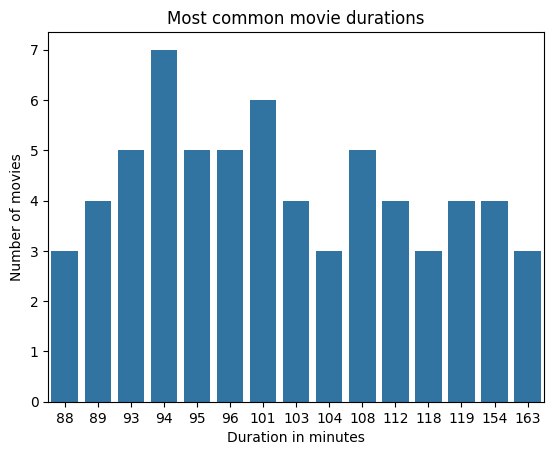

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
top_durations = (
    df['duration']
    .value_counts()
    .head(15)
    .reset_index()
)

top_durations.columns = ['duration', 'count']

sns.barplot(
    data=top_durations,
    x='duration',
    y='count'
)

plt.title('Most common movie durations')
plt.xlabel('Duration in minutes')
plt.ylabel('Number of movies')
plt.show()


In [56]:
df['duration'].mode()

0    94
Name: duration, dtype: int64

In [57]:
df['duration'].value_counts().head(10)

duration
94     7
101    6
108    5
95     5
93     5
96     5
154    4
103    4
119    4
112    4
Name: count, dtype: int64

In [42]:
#Find the most frequent movie duration

duration=df.groupby('duration').agg(cont_d=('duration','count')).nlargest(1,'cont_d').index[0]
duration

np.int64(94)

In [78]:
#Count the number of short action movies from the 1990s
df_action=df[df['genre']=='Action']
df_action.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
10,s508,Movie,Andaz Apna Apna,Rajkumar Santoshi,"Aamir Khan, Salman Khan, Raveena Tandon, Karis...",India,"May 11, 2020",1994,160,Broke and with no concrete plans for the futur...,Action
14,s628,Movie,Austin Powers: The Spy Who Shagged Me,Jay Roach,"Mike Myers, Heather Graham, Michael York, Robe...",United States,"December 1, 2019",1999,95,When diabolical genius Dr. Evil travels back i...,Action
15,s688,Movie,Bad Boys,Michael Bay,"Will Smith, Martin Lawrence, Téa Leoni, Tchéky...",United States,"October 1, 2019",1995,119,"In this fast-paced actioner, two Miami narcoti...",Action
17,s757,Movie,Barsaat,Rajkumar Santoshi,"Twinkle Khanna, Bobby Deol, Danny Denzongpa, R...",India,"April 1, 2018",1995,166,A naïve young man and a rich city girl fall in...,Action
27,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...",Germany,"January 1, 2021",1999,94,A jewel thief returns to his hiding place afte...,Action
30,s1236,Movie,Casino Tycoon,Wong Jing,Wong Jing,Hong Kong,"August 1, 2018",1992,125,"When Japanese troops invade Hong Kong, young B...",Action
31,s1237,Movie,Casino Tycoon 2,Wong Jing,Dennis Chan,Hong Kong,"August 16, 2018",1992,108,Casino mogul Benny Ho wields enormous power. B...,Action
36,s1605,Movie,Dante's Peak,Roger Donaldson,"Pierce Brosnan, Linda Hamilton, Elizabeth Hoff...",United States,"September 1, 2019",1997,108,When a volcanologist comes to investigate the ...,Action
44,s1850,Movie,Dragonheart,Rob Cohen,"Sean Connery, Dennis Quaid, David Thewlis, Pet...",United States,"January 1, 2020",1996,103,In ancient times when majestic fire-breathers ...,Action
49,s2039,Movie,EVANGELION: DEATH (TRUE)²,Hideaki Anno,"Megumi Ogata, Kotono Mitsuishi, Megumi Hayashi...",Japan,"June 21, 2019",1998,69,"Fifteen years after the Second Impact, apathet...",Action


In [79]:
short_movie_count=df_action[df_action['duration'].between(1,90)]['show_id'].count()
short_movie_count

np.int64(7)